In [7]:
y_true = [1,0,1,0,1,1,1,1,0,0,0,1,0,0,0]

y_score = [0.95,0.9,0.85,0.8,0.75,0.7,0.65,0.6,
           0.55,0.5,0.45,0.4,0.35,0.3,0.25]

positive_scores = []
negative_scores = []

for i in range(len(y_true)):
    if y_true[i] == 1:
        positive_scores.append(y_score[i])
    else:
        negative_scores.append(y_score[i])

wins = 0
total_pairs = 0

for pos in positive_scores:
    for neg in negative_scores:
        total_pairs += 1

        if pos > neg:
            wins += 1

roc_auc = wins / total_pairs

print("Positive:", positive_scores)
print("Negative:", negative_scores)

print("Wins:", wins)
print("Total pairs:", total_pairs)

print("ROC-AUC =", round(roc_auc, 2))

Positive: [0.95, 0.85, 0.75, 0.7, 0.65, 0.6, 0.4]
Negative: [0.9, 0.8, 0.55, 0.5, 0.45, 0.35, 0.3, 0.25]
Wins: 42
Total pairs: 56
ROC-AUC = 0.75


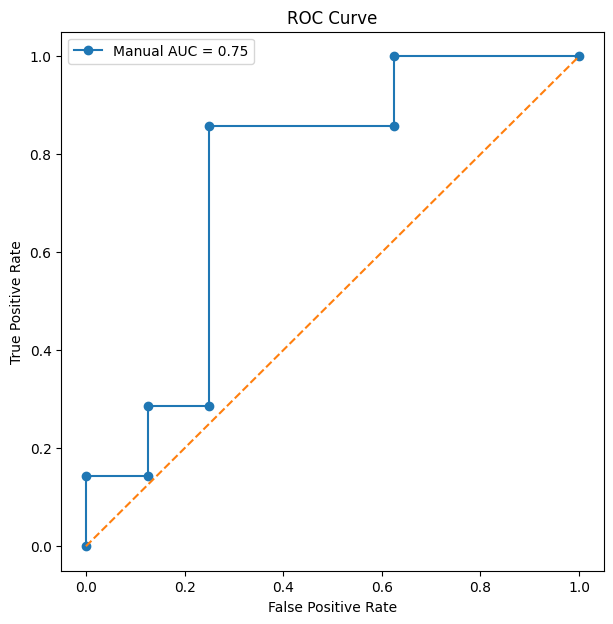

0.75


In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

y_true = [1,0,1,0,1,1,1,1,0,0,0,1,0,0,0]

y_score = [0.95,0.9,0.85,0.8,0.75,0.7,0.65,0.6,
           0.55,0.5,0.45,0.4,0.35,0.3,0.25]

fpr, tpr, thresholds = roc_curve(y_true, y_score)

auc_manual = 0

for i in range(1, len(fpr)):
    width = fpr[i] - fpr[i - 1]
    height = (tpr[i] + tpr[i - 1]) / 2

    auc_manual += width * height

plt.figure(figsize=(7, 7))

plt.plot(fpr, tpr, marker='o',
         label=f'Manual AUC = {auc_manual:.2f}')

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.legend()

plt.show()

print(auc_manual)